# Tillamook LiDAR — Model & Training Visualization

Internal notebook for the strict-binary Tillamook 2×2 experiment.

Expected to be run from `F:\LIDAR\oregon`.

This notebook reads **Phase 3 QC + Phase 4 validation results only** and does **not** evaluate the locked internal test set.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
# If needed:
# ROOT = Path(r"F:\LIDAR\oregon")

PHASE3 = ROOT / "dataset_tillamook_100_binary_15m_split641620"
PHASE4 = ROOT / "phase4_tillamook_binary_2x2"

RUNS = {
    "shallow_7ch": PHASE4 / "shallow_7ch",
    "shallow_3ch": PHASE4 / "shallow_3ch",
    "deep_7ch": PHASE4 / "deep_7ch",
    "deep_3ch": PHASE4 / "deep_3ch",
}

FIGDIR = PHASE4 / "figures"
FIGDIR.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("PHASE4:", PHASE4)
for name, p in RUNS.items():
    print(f"{name:12s} exists={p.exists()}  {p}")


ROOT: f:\LIDAR\oregon
PHASE4: f:\LIDAR\oregon\phase4_tillamook_binary_2x2
shallow_7ch  exists=True  f:\LIDAR\oregon\phase4_tillamook_binary_2x2\shallow_7ch
shallow_3ch  exists=True  f:\LIDAR\oregon\phase4_tillamook_binary_2x2\shallow_3ch
deep_7ch     exists=True  f:\LIDAR\oregon\phase4_tillamook_binary_2x2\deep_7ch
deep_3ch     exists=True  f:\LIDAR\oregon\phase4_tillamook_binary_2x2\deep_3ch


## 1. Dataset / split QC

In [2]:
qc_path = PHASE3 / "phase3_qc.json"
qc = json.loads(qc_path.read_text(encoding="utf-8"))

rows = []
for split in ["train", "validation", "test"]:
    pix = qc["split_pixel_counts"][split]
    rows.append({
        "split": split,
        "tiles": qc["split_tile_counts"][split],
        "patches": qc["split_patch_counts"][split],
        "positive_patches": qc["split_positive_manifest_patch_counts"][split],
        "unique_polygon_ids": qc["split_unique_polygon_ids"][split],
        "GT_positive_%": 100 * pix["positive_fraction"],
    })
qc_df = pd.DataFrame(rows)
display(qc_df.round(3))

print("Mask values:", qc["mask_values"])
print("Spatial violations:", qc["spatial_violation_count"])
print("Cross-split polygon overlap:", qc["cross_split_polygon_overlap_count"])


,split,tiles,patches,positive_patches,unique_polygon_ids,GT_positive_%
0,train,63,3950,1615,227,17.869
1,validation,16,891,313,80,14.260
2,test,19,1210,501,73,21.273


Mask values: [0, 1]
Spatial violations: 0
Cross-split polygon overlap: {'train__validation': 0, 'train__test': 0, 'validation__test': 0}


## 2. Load 2×2 comparison

In [3]:
comparison_path = PHASE4 / "comparison.csv"
comparison = pd.read_csv(comparison_path)
comparison = comparison.sort_values("dice", ascending=False).reset_index(drop=True)
display(comparison.round(4))


,run,architecture,features,parameters,best_epoch,threshold,dice,iou,precision,recall,specificity,fp,fn,gt_positive_fraction,predicted_positive_fraction,pos_weight
0,deep_7ch,Deep,7ch,7767137,21,0.45,0.4085,0.2567,0.2961,0.6584,0.7396,13034704,2844173,0.1426,0.3171,4.5964
1,deep_3ch,Deep,3ch,7765985,26,0.50,0.3434,0.2073,0.2327,0.6543,0.6412,17962608,2878302,0.1426,0.4009,4.5964
2,shallow_7ch,Shallow,7ch,468961,21,0.50,0.3228,0.1924,0.2105,0.6919,0.5683,21611982,2565382,0.1426,0.4688,4.5964
3,shallow_3ch,Shallow,3ch,467809,4,0.45,0.2901,0.1696,0.1826,0.7051,0.4750,26286768,2455430,0.1426,0.5507,4.5964


## 3. Main metric comparison

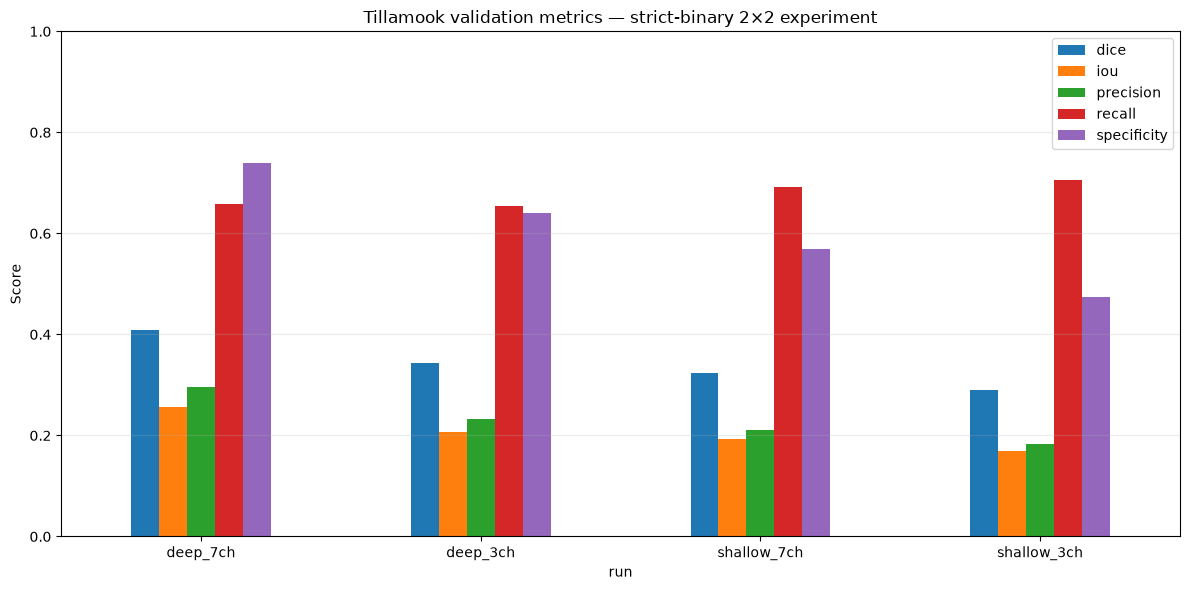

Saved: f:\LIDAR\oregon\phase4_tillamook_binary_2x2\figures\phase4_metric_comparison.png


In [4]:
metric_cols = ["dice", "iou", "precision", "recall", "specificity"]

ax = comparison.set_index("run")[metric_cols].plot(
    kind="bar", figsize=(12, 6), rot=0
)
ax.set_title("Tillamook validation metrics — strict-binary 2×2 experiment")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()

out = FIGDIR / "phase4_metric_comparison.png"
plt.savefig(out, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", out)


## 4. Dice and IoU

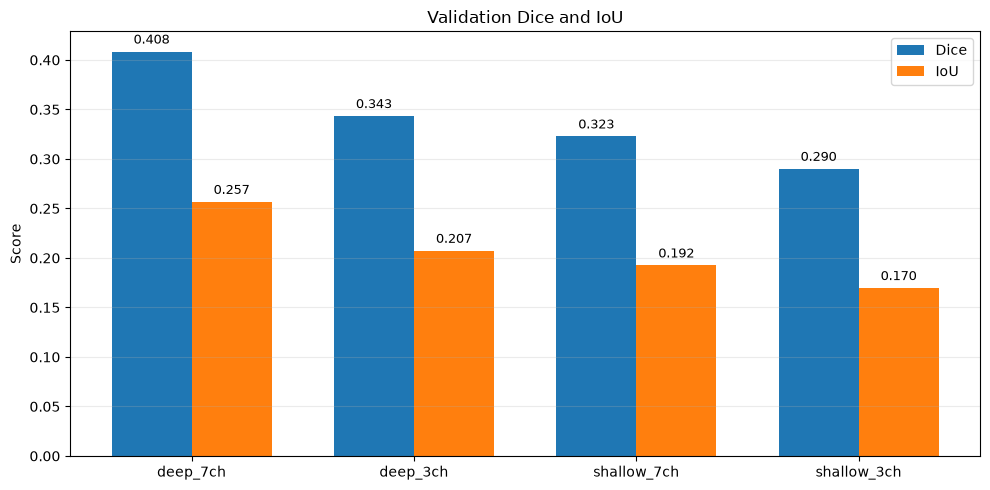

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(comparison))
w = 0.36

ax.bar(x - w/2, comparison["dice"], width=w, label="Dice")
ax.bar(x + w/2, comparison["iou"], width=w, label="IoU")
ax.set_xticks(x)
ax.set_xticklabels(comparison["run"])
ax.set_ylabel("Score")
ax.set_title("Validation Dice and IoU")
ax.legend()
ax.grid(axis="y", alpha=0.25)

for i, v in enumerate(comparison["dice"]):
    ax.text(i - w/2, v + 0.008, f"{v:.3f}", ha="center", fontsize=9)
for i, v in enumerate(comparison["iou"]):
    ax.text(i + w/2, v + 0.008, f"{v:.3f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(FIGDIR / "phase4_dice_iou.png", dpi=180, bbox_inches="tight")
plt.show()


## 5. Predicted positive area vs GT

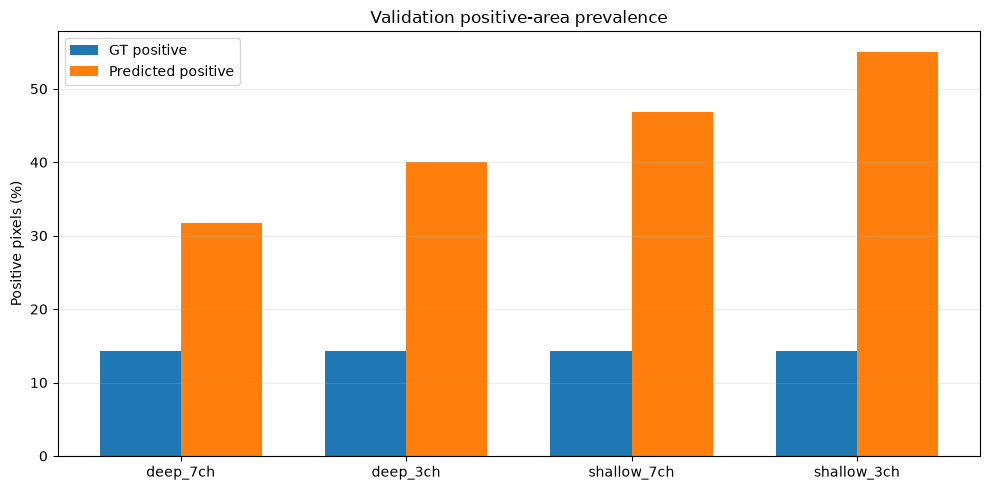

,run,GT_positive_%,Pred_positive_%,Overprediction_ratio
0,deep_7ch,14.26,31.712,2.224
1,deep_3ch,14.26,40.093,2.811
2,shallow_7ch,14.26,46.879,3.287
3,shallow_3ch,14.26,55.073,3.862


In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(comparison))
w = 0.36

ax.bar(x - w/2, 100 * comparison["gt_positive_fraction"], width=w, label="GT positive")
ax.bar(x + w/2, 100 * comparison["predicted_positive_fraction"], width=w, label="Predicted positive")
ax.set_xticks(x)
ax.set_xticklabels(comparison["run"])
ax.set_ylabel("Positive pixels (%)")
ax.set_title("Validation positive-area prevalence")
ax.legend()
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(FIGDIR / "phase4_predicted_vs_gt_positive.png", dpi=180, bbox_inches="tight")
plt.show()

tmp = comparison[["run","gt_positive_fraction","predicted_positive_fraction"]].copy()
tmp["GT_positive_%"] = 100 * tmp["gt_positive_fraction"]
tmp["Pred_positive_%"] = 100 * tmp["predicted_positive_fraction"]
tmp["Overprediction_ratio"] = tmp["predicted_positive_fraction"] / tmp["gt_positive_fraction"]
display(tmp[["run","GT_positive_%","Pred_positive_%","Overprediction_ratio"]].round(3))


## 6. FP / FN burden

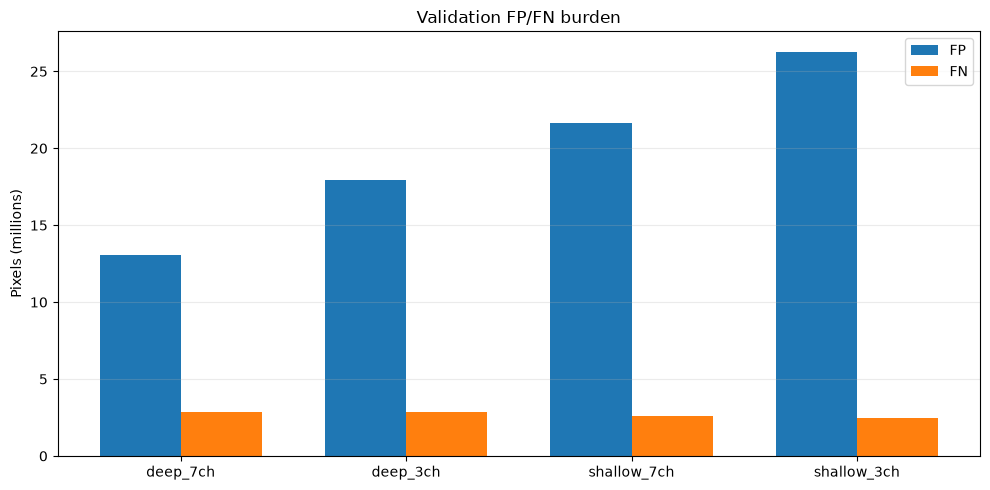

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(comparison))
w = 0.36
ax.bar(x - w/2, comparison["fp"] / 1e6, width=w, label="FP")
ax.bar(x + w/2, comparison["fn"] / 1e6, width=w, label="FN")
ax.set_xticks(x)
ax.set_xticklabels(comparison["run"])
ax.set_ylabel("Pixels (millions)")
ax.set_title("Validation FP/FN burden")
ax.legend()
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(FIGDIR / "phase4_fp_fn.png", dpi=180, bbox_inches="tight")
plt.show()


## 7. Training curves

shallow_7ch 50 epochs
shallow_3ch 50 epochs
deep_7ch 50 epochs
deep_3ch 50 epochs


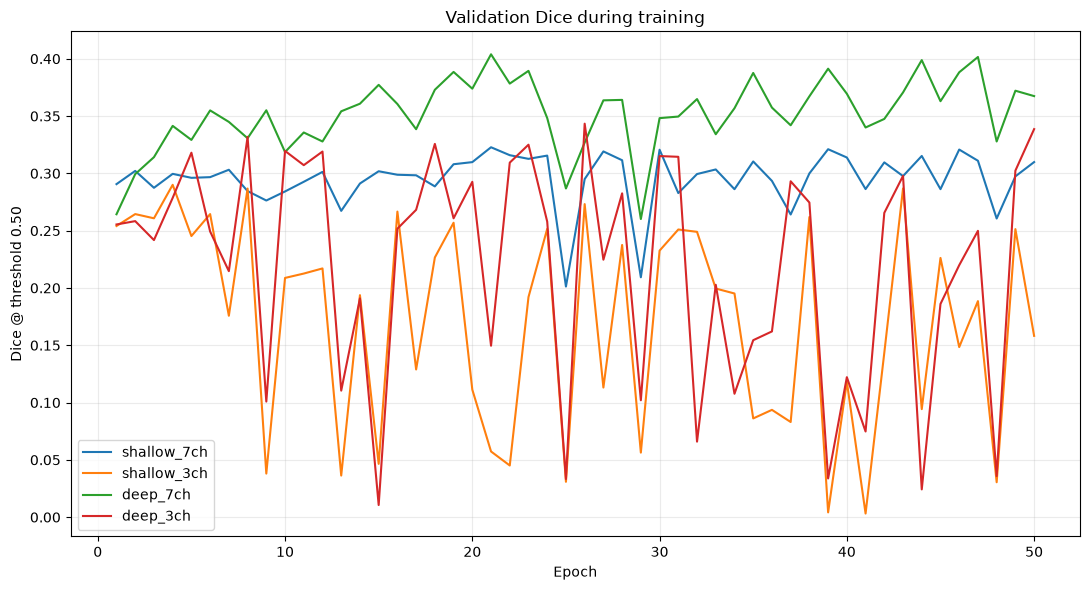

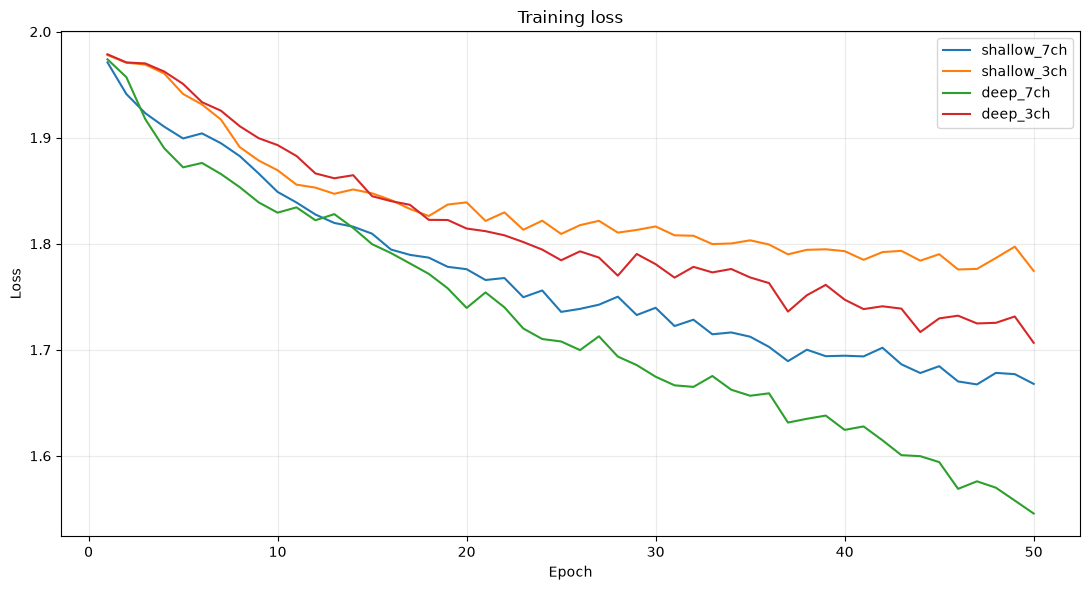

In [8]:
histories = {}
for name, run_dir in RUNS.items():
    p = run_dir / "history.csv"
    if p.exists():
        histories[name] = pd.read_csv(p)
        print(name, len(histories[name]), "epochs")
    else:
        print("Missing:", p)

fig, ax = plt.subplots(figsize=(11, 6))
for name, h in histories.items():
    possible = [c for c in h.columns if "validation" in c.lower() and "dice" in c.lower()]
    if possible:
        ax.plot(h["epoch"], h[possible[0]], label=name)
ax.set_title("Validation Dice during training")
ax.set_xlabel("Epoch")
ax.set_ylabel("Dice @ threshold 0.50")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(FIGDIR / "phase4_validation_dice_curves.png", dpi=180, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(11, 6))
for name, h in histories.items():
    if "train_loss" in h.columns:
        ax.plot(h["epoch"], h["train_loss"], label=name)
ax.set_title("Training loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(FIGDIR / "phase4_training_loss_curves.png", dpi=180, bbox_inches="tight")
plt.show()


## 8. Validation threshold sweeps

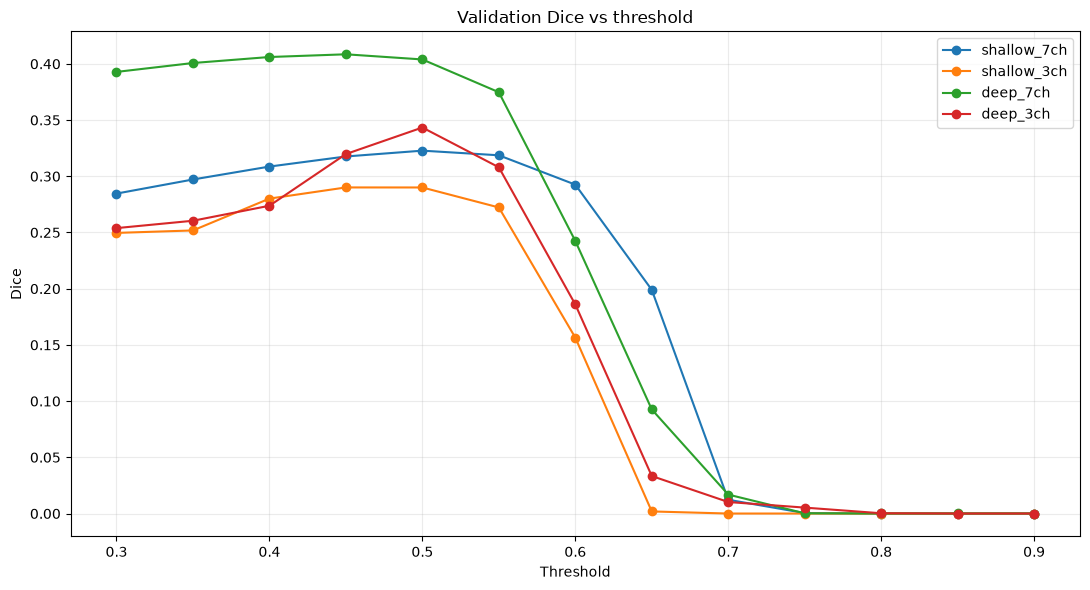

In [9]:
sweeps = {}
for name, run_dir in RUNS.items():
    p = run_dir / "validation_threshold_sweep.csv"
    if p.exists():
        sweeps[name] = pd.read_csv(p)

fig, ax = plt.subplots(figsize=(11, 6))
for name, s in sweeps.items():
    ax.plot(s["threshold"], s["dice"], marker="o", label=name)
ax.set_title("Validation Dice vs threshold")
ax.set_xlabel("Threshold")
ax.set_ylabel("Dice")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(FIGDIR / "phase4_threshold_dice.png", dpi=180, bbox_inches="tight")
plt.show()


### Deep 7ch threshold trade-off

,threshold,dice,iou,precision,recall,specificity,gt_positive_fraction,predicted_positive_fraction
0,0.30,0.3928,0.2444,0.2599,0.8038,0.6194,0.1426,0.4410
1,0.35,0.4007,0.2506,0.2720,0.7609,0.6612,0.1426,0.3990
2,0.40,0.4061,0.2548,0.2835,0.7151,0.6995,0.1426,0.3596
3,0.45,0.4085,0.2567,0.2961,0.6584,0.7396,0.1426,0.3171
4,0.50,0.4039,0.2531,0.3114,0.5746,0.7887,0.1426,0.2631
5,0.55,0.3747,0.2306,0.3321,0.4300,0.8561,0.1426,0.1847
6,0.60,0.2425,0.1380,0.3470,0.1863,0.9417,0.1426,0.0766
7,0.65,0.0926,0.0485,0.3587,0.0532,0.9842,0.1426,0.0211
8,0.70,0.0169,0.0085,0.3693,0.0086,0.9976,0.1426,0.0033
9,0.75,0.0002,0.0001,0.3187,0.0001,1.0000,0.1426,0.0000


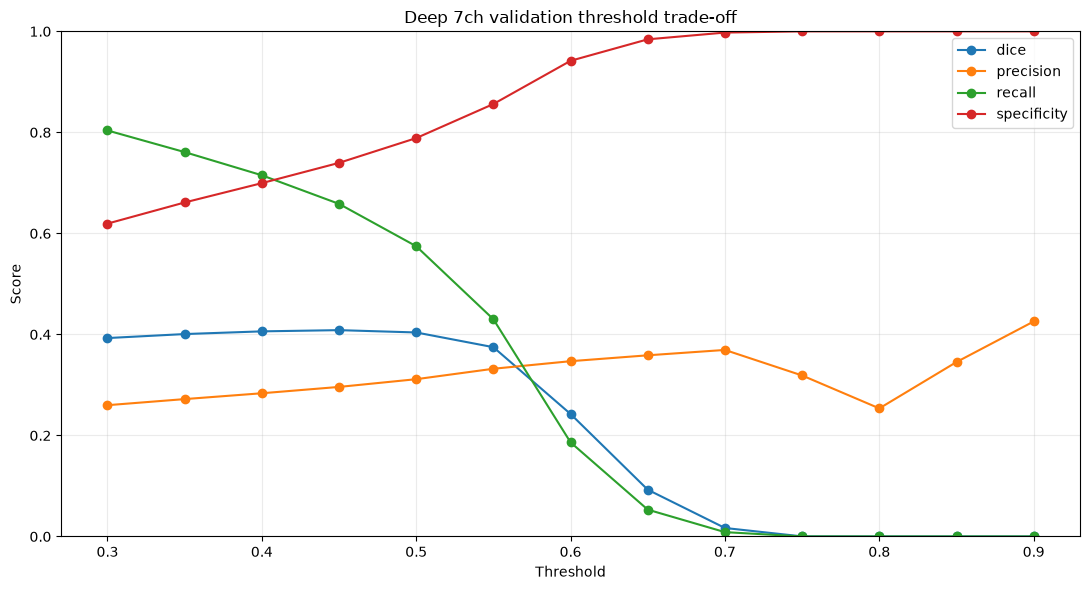

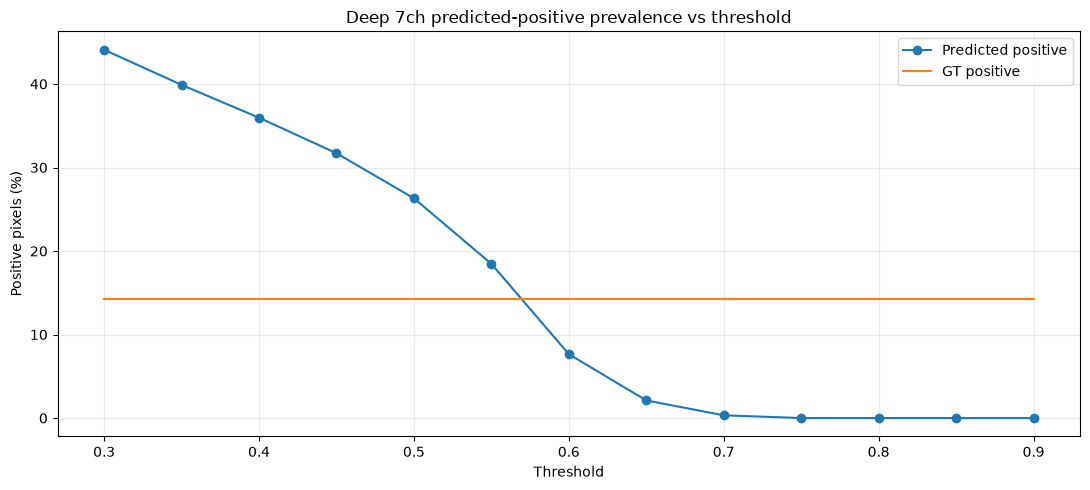

In [10]:
deep7 = sweeps["deep_7ch"]

display(deep7[
    ["threshold","dice","iou","precision","recall","specificity",
     "gt_positive_fraction","predicted_positive_fraction"]
].round(4))

fig, ax = plt.subplots(figsize=(11, 6))
for metric in ["dice", "precision", "recall", "specificity"]:
    ax.plot(deep7["threshold"], deep7[metric], marker="o", label=metric)
ax.set_title("Deep 7ch validation threshold trade-off")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(FIGDIR / "deep7_threshold_tradeoff.png", dpi=180, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(deep7["threshold"], 100*deep7["predicted_positive_fraction"], marker="o", label="Predicted positive")
ax.plot(deep7["threshold"], 100*deep7["gt_positive_fraction"], label="GT positive")
ax.set_title("Deep 7ch predicted-positive prevalence vs threshold")
ax.set_xlabel("Threshold")
ax.set_ylabel("Positive pixels (%)")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(FIGDIR / "deep7_threshold_positive_prevalence.png", dpi=180, bbox_inches="tight")
plt.show()


## 9. Model size vs performance

,run,parameters,dice,iou,params_million
0,deep_7ch,7767137,0.4085,0.2567,7.7671
1,deep_3ch,7765985,0.3434,0.2073,7.7660
2,shallow_7ch,468961,0.3228,0.1924,0.4690
3,shallow_3ch,467809,0.2901,0.1696,0.4678


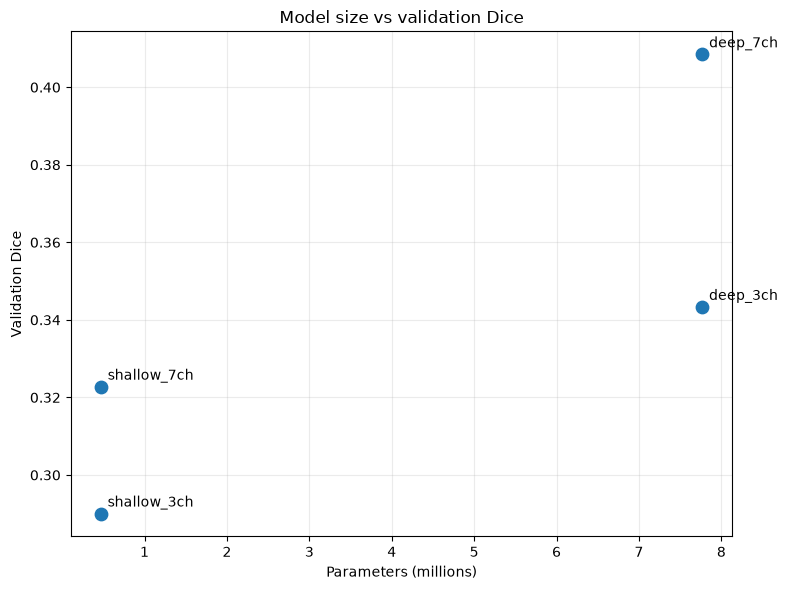

In [11]:
eff = comparison[["run","parameters","dice","iou"]].copy()
eff["params_million"] = eff["parameters"] / 1e6
display(eff.round(4))

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(eff["params_million"], eff["dice"], s=80)
for _, r in eff.iterrows():
    ax.annotate(r["run"], (r["params_million"], r["dice"]), xytext=(5,5), textcoords="offset points")
ax.set_xlabel("Parameters (millions)")
ax.set_ylabel("Validation Dice")
ax.set_title("Model size vs validation Dice")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(FIGDIR / "phase4_params_vs_dice.png", dpi=180, bbox_inches="tight")
plt.show()


## 10. Current development winner

In [12]:
winner = comparison.iloc[0]
summary = pd.Series({
    "run": winner["run"],
    "best_epoch": int(winner["best_epoch"]),
    "threshold": winner["threshold"],
    "dice": winner["dice"],
    "iou": winner["iou"],
    "precision": winner["precision"],
    "recall": winner["recall"],
    "specificity": winner["specificity"],
    "GT_positive_%": 100 * winner["gt_positive_fraction"],
    "predicted_positive_%": 100 * winner["predicted_positive_fraction"],
})
display(summary)


run                      deep_7ch
best_epoch                     21
threshold                    0.45
dice                     0.408491
iou                      0.256669
precision                0.296091
recall                   0.658443
specificity              0.739647
GT_positive_%           14.260496
predicted_positive_%    31.712254
dtype: object

## Protocol reminder

- These are **validation-only** plots.
- Do **not** add the locked `test` split while the model is still being tuned.
- Current best development baseline is `deep_7ch`.
- Main current weakness: false-positive / positive-area overprediction.
